In [63]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

import numpy as np

## Task 1: Numerical differentiation

The definition of a derivative is
$$ \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h} $$

Approximate **forward-difference:**
$$ \frac{df}{dx} \approx \frac{f(x+h) - f(x)}{h} $$


In [64]:
# 1. 
x = 1
h = np.logspace(-12,-1,base=10)

def f(x):
    return x**0.8

fd_vals = (f(x+h) - f(x))/h

print(f"Derivatives: {fd_vals}")

Derivatives: [0.80002671 0.80007583 0.79996333 0.79999546 0.80001341 0.80000359
 0.80000111 0.80000168 0.80000047 0.79999883 0.80000008 0.79999979
 0.80000006 0.79999994 0.79999998 0.79999999 0.79999997 0.80000001
 0.8        0.8        0.8        0.8        0.79999999 0.79999999
 0.79999998 0.79999997 0.79999995 0.79999991 0.79999985 0.79999974
 0.79999957 0.79999927 0.79999878 0.79999795 0.79999657 0.79999424
 0.79999035 0.79998381 0.79997286 0.79995449 0.7999237  0.79987209
 0.79978561 0.79964077 0.79939836 0.7989932  0.79831747 0.79719452
 0.79533931 0.79230345]


### 2. 

if $f(x) = x^{0.8}$

then $$f'(x) = 0.8 x^{0.8-1}$$
$$= f'(x) = 0.8 x^{0.2} $$

Then at x = 1,
$$  f'(x)|_{x=1} = 0.8 \times 1^{0.2} $$

$$= 0.8$$


In [65]:
# 2.  
exact_val = 0.8

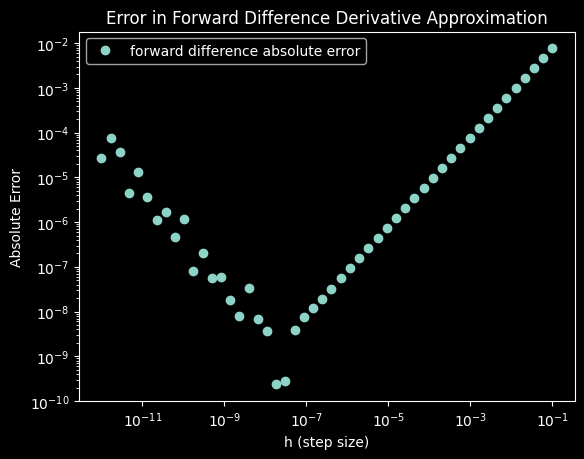

In [66]:
# 3.  

# We did absolute error in last Guide
# absolute error of your approximate values as a function of h on log-log scale.

abs_error = np.abs(fd_vals-exact_val)

plt.plot(h,abs_error,'o',label='forward difference absolute error')
plt.loglog()
plt.xlabel('h (step size)')
plt.ylabel('Absolute Error')
plt.title('Error in Forward Difference Derivative Approximation')
plt.legend()
plt.show()

### 4. 

??? Comment on what you see. (Note: you will likely see your error going up again at really small h. What do you think this is from? Hint: Recall rounding error from an Guide 2; if there is a constant error in evaluating f, how will this affect the error in the derivative?)


### 5. 

The general formula is:
$f(x+h)=f(x)+hf^{\prime }(x)+\frac{h^{2}}{2!}f^{\prime \prime }(x)+\frac{h^{3}}{3!}f^{\prime \prime \prime }(x)+\cdots +\frac{h^{n}}{n!}f^{(n)}(x)+\cdots$              


Taylor expansions:
$$ f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + ... $$
$$ f(x-h) = f(x) - hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(x) + ... $$

Subtracting the second from the first:
$$ f(x+h) - f(x-h) = 2hf'(x) + \frac{2h^3}{6}f'''(x) + ... $$

Now, what we have to do is, solve for $f'(x)$, putting it on the left side
$$ f'(x) = \frac{f(x+h) - f(x-h)}{2h} - \frac{h^2}{6}f'''(x) + ... $$

The extreme end factor on the right side is a function O of order $h^2$, we can write it as:
$$ f'(x) \approx \frac{f(x+h) - f(x-h)}{2h} - O(h^2) $$

$$ f'(x) + O(h^2) \approx \frac{f(x+h) - f(x-h)}{2h} $$

$O(h^2)$ is the error factor, the difference between the central difference function and the f'(x). 

Note that: For small h values, this value should be negligible, at least that is what calculus tells us


Central Difference Values: [8.00026712e-25 2.24953509e-24 6.32470073e-24 1.77838710e-23
 5.00048146e-23 1.40600745e-22 3.95337617e-22 1.11159873e-21
 3.12555380e-21 8.78832207e-21 2.47107513e-20 6.94808918e-20
 1.95364261e-19 5.49319080e-19 1.54455815e-18 4.34294031e-18
 1.22113434e-17 3.43354740e-17 9.65434117e-17 2.71457743e-16
 7.63276381e-16 2.14615664e-15 6.03449605e-15 1.69676071e-14
 4.77089865e-14 1.34146635e-13 3.77189309e-13 1.06056909e-12
 2.98207498e-12 8.38490507e-12 2.35764136e-11 6.62914218e-11
 1.86396145e-10 5.24102846e-10 1.47365598e-09 4.14357974e-09
 1.16507878e-08 3.27593206e-08 9.21116324e-08 2.58996607e-07
 7.28238569e-07 2.04763855e-06 5.75748704e-06 1.61887303e-05
 4.55190318e-05 1.27989517e-04 3.59881090e-04 1.01193539e-03
 2.84558951e-03 8.00321132e-03]


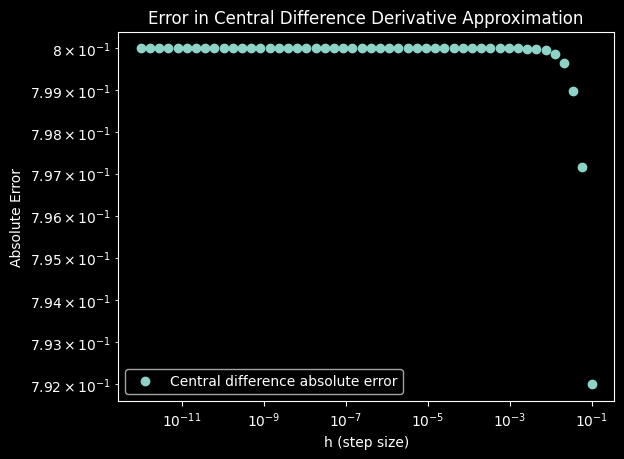

In [67]:
# 6.  

x = 1
h = np.logspace(-12,-1,base=10)

def f(x):
    return x**0.8

cd_vals = (f(x+h) - f(x-h))/2*h

print(f"Central Difference Values: {cd_vals}")


# Error Plot


abs_error = np.abs(cd_vals-exact_val)

plt.plot(h,abs_error,'o',label='Central difference absolute error')
plt.loglog()
plt.xlabel('h (step size)')
plt.ylabel('Absolute Error')
plt.title('Error in Central Difference Derivative Approximation')
plt.legend()
plt.show()


Note
**Background reading: Solutions to ordinary differential equations**


However, all higher-order ODEs can be represented as a system of coupled first-order ODEs that only involve first-order derivatives. Thus, in general, the ODEs that we encounter in physics can be represented as the following set of equations,
d𝑥𝑖d𝑡=𝑓𝑖(𝑡,𝑥1,𝑥2,…,𝑥𝑛)(1)
Here 𝑖=1,…,𝑛, and we know the functions 𝑓𝑖. For example, consider Newton’s 2nd law:
𝑚d2𝑥d𝑡2=𝐹(𝑡,𝑥,𝑣)
where x is the position of the particle and F is the force acting on it. This 2nd-order differential equation can be written as two coupled 1st-order differential equations,
d𝑥d𝑡=𝑣(𝑡) 𝑚d𝑣d𝑡=𝐹(𝑡,𝑥,𝑣)

Here we track both the position x and velocity v as a function of time. For example, an object in free fall would have equations,
d𝑥d𝑡=𝑣 d𝑣d𝑡=−𝑔

*As we will see, this forward iteration using truncated approximations to reality can accumulate error, potentially leading to divergences.*

## Task 2: Exploring numerical methods for solving ODEs

Details: Consider the following kinematics problem. 

A ball starts at a height of 1 m and is thrown up in the air with an initial velocity of 5 m/s.

### 1.  

Plot Height, as a function of time from t = 0 to 1 s using the 1D kinematics Sols.

$s = ut + \frac{1}{2} at^2$
or
$x_f  =  x_i + ut + \frac{1}{2} at^2$




$v^2 - u^2 = 2 as$


$a = \frac{v-u}{t}$


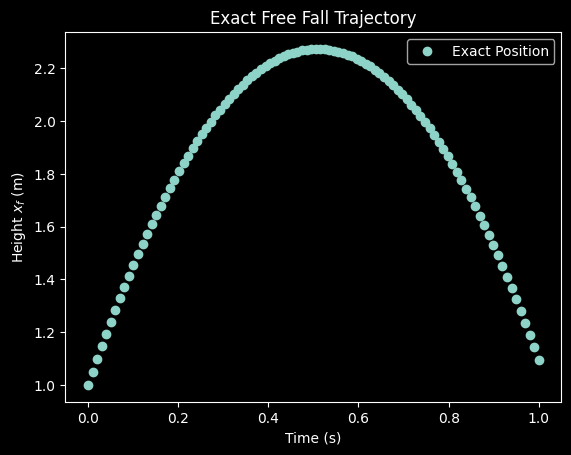

In [68]:
# 1 contd.

u = 5 # m/s
g = -9.81 # m/s^2
xi = 1 # m

def xf(t,u=5,a=-9.81,xi=1): # First equation above
    return xi + (u*t) + ((1/2)*a*t**2)


# Please note that I am starting at t = 0.0000001. Just to avoid any potential Zero Division error

t = np.linspace(0.0000001, 1,100) 

exact_vals = xf(t)
plt.plot(t, exact_vals,'o', label='Exact Position')
plt.xlabel('Time (s)')
plt.ylabel('Height $x_f$ (m)')
plt.title('Exact Free Fall Trajectory')
plt.legend()

plt.show()




### 2. 

**Euler Method**

The Euler Method The simplest numerical approach is the Euler method. For a set of first-order differential equations, the solution at the next time step, 

$t_{i+1}=t_{i}+h$ (1) , 


is calculated as: 

$ x_{i+1} = x_{i} + hf(t_{i},x_{i}) (2) $

Application: Free Fall In the case of free fall, we apply this method to update both velocity and position. Given an increment in time $h=\Delta t$, the update rules are: 

Position Update: 

$x_{i+1}=x_{i}+hv_{i}$ (3)

Velocity Update: 

$v_{i+1}=v_{i}-hg$ (4)

In  these equations, $g$ represents the acceleration due to gravity, and $h$ defines the step size of the simulation.


---

In [69]:
# 2.  contd. 

#??? Error, Trouble Shoot!

# We can form the above (1) equation just by using np.arrange, that adds a step of h on the start

h = 0.01 # delta t = 0.01 s
t_e_lst = np.arange(0.0000001,1+h,h)
xi = 5 # m
vi = 5 # m/s
g = -9.81 # m/s^2

x_e_lst = [xi] # Our Euler List
v_e_lst = [vi] # Our Euler List

for i in range(len(t_e_lst)):
    xi_next = x_e_lst[i] + (h * v_e_lst[i])
    x_e_lst.append(xi_next)
    
    vi_next = v_e_lst[i] + (h * g)
    v_e_lst.append(vi_next)
    



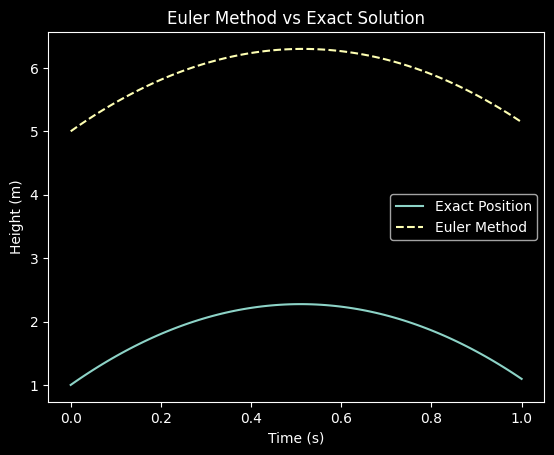

In [70]:
# 3.  

plt.plot(t, exact_vals, label='Exact Position')
plt.plot(t_e_lst, x_e_lst[:-1], '--', label='Euler Method')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Euler Method vs Exact Solution')
plt.legend()

plt.show()

**Better Methods: nth-order Runge-Kutta**

In [71]:
# 4.  
import scipy

print(scipy.integrate.solve_ivp.__doc__)

import scipy as sp
from scipy.integrate import solve_ivp


Solve an initial value problem for a system of ODEs.

    This function numerically integrates a system of ordinary differential
    equations given an initial value::

        dy / dt = f(t, y)
        y(t0) = y0

    Here t is a 1-D independent variable (time), y(t) is an
    N-D vector-valued function (state), and an N-D
    vector-valued function f(t, y) determines the differential equations.
    The goal is to find y(t) approximately satisfying the differential
    equations, given an initial value y(t0)=y0.

    Some of the solvers support integration in the complex domain, but note
    that for stiff ODE solvers, the right-hand side must be
    complex-differentiable (satisfy Cauchy-Riemann equations [11]_).
    To solve a problem in the complex domain, pass y0 with a complex data type.
    Another option always available is to rewrite your problem for real and
    imaginary parts separately.

    Parameters
    ----------
    fun : callable
        Right-hand side of the system

In [72]:
# 5.  

def free_fall_derivs(t, y):
    # y[0] is position, y[1] is velocity
    # returns [dy/dt, dv/dt]
    return [y[1], -g]


In [73]:
# 6.  

x0,v0 = 1 ,5 #m , m/s
sol = solve_ivp(free_fall_derivs, [0, 1], [x0, v0])


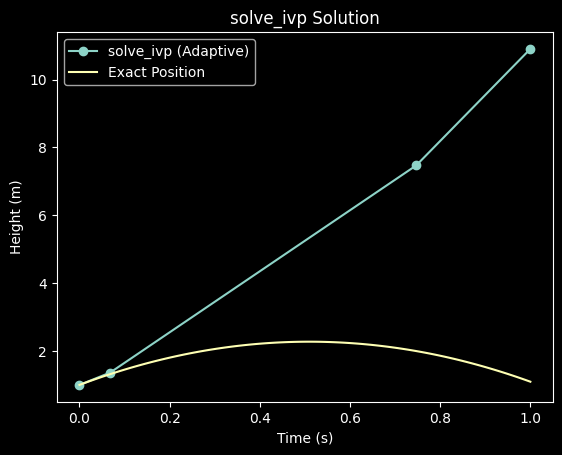

In [75]:
# 7.  

plt.plot(sol.t, sol.y[0], 'o-', label='solve_ivp (Adaptive)')
plt.plot(t, exact_vals, label='Exact Position')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('solve_ivp Solution')
plt.legend()
plt.show()